### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


# SQL Agent with LangGraph

**Intelligent database query agent using LangGraph workflow**

This notebook implements a SQL agent that can:
1. **Understand natural language questions** and convert them to SQL queries
2. **Validate queries for safety** before execution (prevents SQL injection)
3. **Execute queries** on an employees database
4. **Fix errors automatically** if queries fail
5. **Provide detailed answers** with proper formatting

## Key Features:
- **Multi-step workflow**: Schema retrieval → Query generation → Validation → Execution
- **Error handling**: Automatically fixes failed queries up to 3 attempts
- **Safety-first**: Only SELECT queries allowed, validates for SQL injection patterns
- **Tool-based architecture**: Dedicated tools for each step of the SQL workflow

## Tools Available:
- `get_database_schema`: Get table structure and column information
- `generate_sql_query`: Convert natural language to SQL
- `validate_sql_query`: Check query safety and syntax
- `execute_sql_query`: Run validated queries
- `fix_sql_error`: Automatically correct failed queries

Database: **employees_db** (SQLite) with employee records, salaries, departments, and titles.

https://github.com/fracpete/employees-db-sqlite

In [2]:
from typing_extensions import TypedDict, Annotated
from typing import List
import os
import re 
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

from langchain_community.utilities import SQLDatabase

from dotenv import load_dotenv
load_dotenv()

d:\coding\ai_learning\laxmimerit\Agentic-RAG-with-LangGraph-and-Ollama\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\AppData\Local\Temp\ipykernel_19200\3153264945.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


True

In [3]:
# =============================================================================
# Configuration
# =============================================================================

# LLM_MODEL = "qwen3"
LLM_MODEL = "gpt-oss"
# LLM_MODEL = "granite4:latest"
BASE_URL = "http://localhost:11434"

llm = ChatOllama(model=LLM_MODEL, base_url=BASE_URL, reasoning=True)

response = llm.invoke("Hello, how are you?")
response.pretty_print()

================================== Ai Message ==================================

Hi there! I’m doing great—thanks for asking. How about you? What’s on your mind today?


In [4]:
# response.additional_kwargs['reasoning_content']

In [5]:
# =============================================================================
# Database Setup
# =============================================================================

db = SQLDatabase.from_uri('sqlite:///db/employees_db-full-1.0.6.db')

tables = db.get_usable_table_names()


SCHEMA = db.get_table_info()

In [6]:
print(SCHEMA)


CREATE TABLE departments (
	dept_no CHAR(4) NOT NULL, 
	dept_name VARCHAR(40) NOT NULL, 
	PRIMARY KEY (dept_no), 
	UNIQUE (dept_name)
)

/*
3 rows from departments table:
dept_no	dept_name
d009	Customer Service
d005	Development
d002	Finance
*/


CREATE TABLE dept_emp (
	emp_no INTEGER NOT NULL, 
	dept_no CHAR(4) NOT NULL, 
	from_date DATE NOT NULL, 
	to_date DATE NOT NULL, 
	PRIMARY KEY (emp_no, dept_no), 
	FOREIGN KEY(dept_no) REFERENCES departments (dept_no), 
	FOREIGN KEY(emp_no) REFERENCES employees (emp_no)
)

/*
3 rows from dept_emp table:
emp_no	dept_no	from_date	to_date
10001	d005	1986-06-26	9999-01-01
10002	d007	1996-08-03	9999-01-01
10003	d004	1995-12-03	9999-01-01
*/


CREATE TABLE dept_manager (
	dept_no CHAR(4) NOT NULL, 
	emp_no INTEGER NOT NULL, 
	from_date DATE NOT NULL, 
	to_date DATE NOT NULL, 
	PRIMARY KEY (emp_no, dept_no), 
	FOREIGN KEY(dept_no) REFERENCES departments (dept_no), 
	FOREIGN KEY(emp_no) REFERENCES employees (emp_no)
)

/*
3 rows from dept_manager tab

### SQL Tools

In [7]:
# =============================================================================
# SQL Tools
# =============================================================================

@tool
def get_database_schema(table_name: str = None):
    """Get database schema information for SQL query generation.
    Use this first to understand table structure before creating queries."""

    if table_name:
        tables = db.get_usable_table_names()
        if table_name.lower() in [t.lower() for t in tables]:
            result = db.get_table_info([table_name])
            return result
        
        else:
            return f"Error: Table '{table_name}' not found. Available tables: '{', '.join(tables)}'"
    else:
        return SCHEMA

In [8]:
# get_database_schema.invoke('ht')

In [9]:
@tool
def generate_sql_query(question: str, schema_info: str=None):
    """Generate a SQL SELECT query from a natural language question using database schema.
        Always use this after getting schema information."""
    
    schema_to_use = schema_info if schema_info else SCHEMA

    prompt = f"""Based on this database schema:
                {schema_to_use}

                Generate a SQL query to answer this question: {question}

                Rules:
                - Use only SELECT statements
                - Include only existing columns and tables
                - Add appropriate WHERE, GROUP BY, ORDER BY clauses as needed
                - Limit results to 10 rows unless specified otherwise
                - Use proper SQL syntax for SQLite

                Return only the SQL query, nothing else."""
    
    response = llm.invoke(prompt)
    sql_query = response.content.strip()
    print(f"[TOOL] Generated SQL Query: {sql_query[:30]}...")
    return sql_query

In [10]:
generate_sql_query.invoke("how many employees are there?")

[TOOL] Generated SQL Query: SELECT COUNT(*) AS employee_co...


'SELECT COUNT(*) AS employee_count\nFROM employees;'

In [11]:
# 'SELECT COUNT(*) FROM employees;'

# ```sql
# 'SELECT COUNT(*) FROM employees;'
# ```

In [12]:
@tool
def validate_sql_query(query: str):
    """Validate SQL query for safety and syntax before execution.
        Returns 'Valid: <query>' if safe or 'Error: <message>' if unsafe."""
    
    clean_query = query.strip()

    # remove sql code block
    clean_query = re.sub(r'```sql\s*', '', clean_query, flags=re.IGNORECASE)
    clean_query = re.sub(r'```\s*', '', clean_query, flags=re.IGNORECASE)

    clean_query = clean_query.strip().rstrip(';')

    if not clean_query.lower().startswith('select'):
        return "Error: only 'select' statements are allowed."
    
    # Check 2: Block dangerous SQL keywords
    dangerous_keywords = ['INSERT', 'UPDATE', 'DELETE', 'ALTER', 'DROP', 'CREATE', 'TRUNCATE']
    query_upper = clean_query

    for keyword in dangerous_keywords:
        if keyword in query_upper:
            return f"Error: {keyword} operations are not allowed."
        
    print("[TOOL] Your sql query is validated. Passed!")
    return clean_query


In [13]:
validate_sql_query.invoke('SELECT COUNT(*) FROM employees;')

[TOOL] Your sql query is validated. Passed!


'SELECT COUNT(*) FROM employees'

In [14]:
@tool
def execute_sql_query(sql_query: str):
    """Execute a validated SQL query and return results.
    Only use this after validating the query for safety."""


    query = validate_sql_query.invoke(sql_query)
    if query.startswith('Error:'):
        return f"Query '{sql_query}' validation failed with Error: {query}"
    
    result = db.run(query)

    if result:
        return  f"Query Results: {result}"
    
    else:
        return f"Query Executed Sucessfully but No Result was Found!"
    
    


In [15]:
execute_sql_query.invoke('SELECT COUNT(*) FROM employees;')

[TOOL] Your sql query is validated. Passed!


'Query Results: [(300024,)]'

In [16]:
@tool
def fix_sql_error(original_query: str, error_message: str, question):
    """Fix a failed SQL query by analyzing the error and generating a corrected version.
        Use this when validation or execution fails."""
    
    fix_prompt = f"""The following SQL query failed:
                    Query: {original_query}
                    Error: {error_message}
                    Original Question: {question}

                    Database Schema:
                    {SCHEMA}

                    Analyze the error and provide a corrected SQL query that:
                    1. Fixes the specific error mentioned
                    2. Still answers the original question
                    3. Uses only valid table and column names from the schema
                    4. Follows SQLite syntax rules

                    Return only the corrected SQL query, nothing else."""
    
    response = llm.invoke(fix_prompt)
    query = response.content.strip()

    print(f"[TOOL] Generated fixed SQL Query.")

    return query

### MySQL Agent Creation

In [17]:
# =============================================================================
# State and Tools
# =============================================================================
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

tools = [
    get_database_schema,
    generate_sql_query,
    execute_sql_query,
    fix_sql_error
]

llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools

_ChatModelBinding(bound=ChatOllama(output_version=None, model='gpt-oss', reasoning=True, base_url='http://localhost:11434'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_database_schema', 'description': 'Get database schema information for SQL query generation.\n    Use this first to understand table structure before creating queries.', 'parameters': {'properties': {'table_name': {'default': None, 'type': 'string'}}, 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'generate_sql_query', 'description': 'Generate a SQL SELECT query from a natural language question using database schema.\n        Always use this after getting schema information.', 'parameters': {'properties': {'question': {'type': 'string'}, 'schema_info': {'default': None, 'type': 'string'}}, 'required': ['question'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'execute_sql_query', 'description': 'Execute a validated SQL query and return results.\n    Only use this aft

In [19]:
# =============================================================================
# LangGraph Agent Node
# =============================================================================

def agent_node(state: AgentState):
    
    system_prompt = f"""You are an expert SQL analyst working with an employees database.

                    Database Schema:
                    {SCHEMA}

                    Your workflow for answering questions:
                    1. Use `get_database_schema` first to understand available tables and columns (if needed)
                    2. Use `generate_sql_query` to create SQL based on the question
                    3. Use `execute_sql_query` to run the validated query
                    4. If there's an error, use `fix_sql_error` to correct it and try again (up to 3 times)

                    Rules:
                    - Always follow the workflow step by step
                    - If a query fails, use the fix tool and try again
                    - Provide clear, informative answers
                    - Be precise with table and column names
                    - Handle errors gracefully and try to fix them
                    - If you fail after 3 attempts, explain what went wrong

                    Available tools:
                    - get_database_schema: Get table structure info
                    - generate_sql_query: Create SQL from question
                    - execute_sql_query: Run the query
                    - fix_sql_error: Fix failed queries

                    Remember: Always validate queries before executing them for safety."""
    

    messages = [SystemMessage(system_prompt)] + state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [20]:
llm_with_tools.invoke('how many employees are there?')

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "how many employees are there?" We have a database presumably with employees table. Need to get schema, then generate SQL query for count. Then execute. Let\'s call get_database_schema on appropriate table: probably \'employees\' or maybe \'Employee\', but likely \'employee\'. We\'ll try \'employees\'.\n\n'}, response_metadata={'model': 'gpt-oss', 'created_at': '2026-06-23T03:32:36.296909913Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13554104338, 'load_duration': 890365256, 'prompt_eval_count': 280, 'prompt_eval_duration': 3667435000, 'eval_count': 88, 'eval_duration': 8969858000, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--019ef289-4453-7e12-9d44-b953b2f2f9f3-0', tool_calls=[{'name': 'get_database_schema', 'args': {'table_name': 'employees'}, 'id': 'ef11012f-2e89-49a7-bd0e-84d8fc74742e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [21]:
# =============================================================================
# Router Logic
# =============================================================================

def should_continue(state: AgentState):

    last_message = state['messages'][-1]

    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        print("[TOOL] Calling the tool")
        for tc in last_message.tool_calls:
            print(f"Callling tool: '{tc['name']}' with Args: '{tc['args']}'")

        return 'tools'

    else:
        print("[AGENT] Agent is processing your request...")
        return END



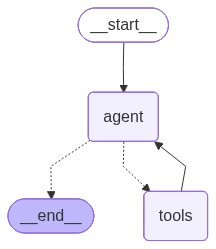

In [22]:
# =============================================================================
# Build Graph
# =============================================================================

def create_sql_agent():

    builder = StateGraph(AgentState)

    # add nodes
    builder.add_node('agent', agent_node)
    builder.add_node('tools', ToolNode(tools))

    # add edges
    builder.add_edge(START, 'agent')
    builder.add_edge('tools', 'agent')

    # add router
    builder.add_conditional_edges('agent', should_continue, ['tools', END])

    graph = builder.compile()

    return graph

agent = create_sql_agent()
agent

In [23]:
query = "how many employees are there"
result = agent.invoke({'messages': [query]})

[TOOL] Calling the tool
Callling tool: 'get_database_schema' with Args: '{'table_name': 'employees'}'
[TOOL] Calling the tool
Callling tool: 'generate_sql_query' with Args: '{'question': 'how many employees are there', 'schema_info': 'CREATE TABLE employees (\n\temp_no INTEGER NOT NULL, \n\tbirth_date DATE NOT NULL, \n\tfirst_name VARCHAR(14) NOT NULL, \n\tlast_name VARCHAR(16) NOT NULL, \n\tgender TEXT NOT NULL, \n\thire_date DATE NOT NULL, \n\tPRIMARY KEY (emp_no)\n)\n\n/*\n3 rows from employees table:\nemp_no\tbirth_date\tfirst_name\tlast_name\tgender\thire_date\n10001\t1953-09-02\tGeorgi\tFacello\tM\t1986-06-26\n10002\t1964-06-02\tBezalel\tSimmel\tF\t1985-11-21\n10003\t1959-12-03\tParto\tBamford\tM\t1986-08-28\n*/'}'
[TOOL] Generated SQL Query: SELECT COUNT(*) AS employee_co...
[TOOL] Calling the tool
Callling tool: 'execute_sql_query' with Args: '{'sql_query': 'SELECT COUNT(*) AS employee_count FROM employees LIMIT 10;'}'
[TOOL] Your sql query is validated. Passed!
[AGENT] Agent i

In [24]:
db.run('SELECT COUNT(*) FROM employees;')

'[(300024,)]'

In [25]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

There are **300 024** employees in the database.


In [27]:
query = "What is the average salary of each department show me top 5 department?"
result = agent.invoke({'messages': [query]})
result['messages'][-1].pretty_print()

[TOOL] Calling the tool
Callling tool: 'get_database_schema' with Args: '{'table_name': 'departments'}'
[TOOL] Calling the tool
Callling tool: 'get_database_schema' with Args: '{'table_name': 'dept_emp'}'
[TOOL] Calling the tool
Callling tool: 'get_database_schema' with Args: '{'table_name': 'salaries'}'
[TOOL] Calling the tool
Callling tool: 'generate_sql_query' with Args: '{'question': 'What is the average salary of each department show me top 5 department?', 'schema_info': 'departments(dept_no CHAR(4), dept_name VARCHAR(40)); dept_emp(emp_no INTEGER, dept_no CHAR(4), from_date DATE, to_date DATE); salaries(emp_no INTEGER, salary INTEGER, from_date DATE, to_date DATE).'}'
[TOOL] Generated SQL Query: SELECT 
    d.dept_no,
    d.d...
[TOOL] Calling the tool
Callling tool: 'execute_sql_query' with Args: '{'sql_query': 'SELECT \n    d.dept_no,\n    d.dept_name,\n    AVG(s.salary) AS average_salary\nFROM \n    departments d\nJOIN \n    dept_emp de ON d.dept_no = de.dept_no\nJOIN \n    sa

In [ ]:
query = "Show me the top 5 highest paid employees with their title and salaries?"
result = agent.invoke({'messages': [query]})
result['messages'][-1].pretty_print()